In [2]:
from src.features import moment_like_features, prepare_targets
from src.hcr import fit_lasso, plot_example_densities
from src.evaluation import mean_log_likelihood, mse_evaluation

def eval(X_train_norm, X_test_norm, 
         y_train_norm, y_test_norm,
         y_test, y_denorm,
         N_feature, N_target, 
         method="softplus", 
         a=1, b=1, eps=1e-6):
    
    print(f"----- Target deg. {N_target}, feature deg. {N_feature} -----")

    V_train = moment_like_features(X_train_norm, N_feature)
    V_test  = moment_like_features(X_test_norm, N_feature)
    targets_train = prepare_targets(y_train_norm, N_target)

    models = []
    for n in range(N_target):
        models.append(fit_lasso(V_train, targets_train[n]))

    plot_example_densities(V_test, y_test_norm, 
                           models, method="softplus", a=a, b=b, eps=eps,
                           name=f"Example densities (deg. {N_target}, feature deg. {N_feature})",
                           seed=33, raw=True)

    ll = mean_log_likelihood(V_test, y_test_norm, models,
                             method=method, a=a, b=b, eps=eps)
    print(f"CL mean log-likelihood: {ll:.4f}")

    mse = mse_evaluation(V_test, y_test, models, y_denorm,
                         method=method, a=a, b=b, eps=eps)
    print(f"CL test MSE: {mse:.4f}")

In [3]:
from src.cv import cross_validate

def cv_eval(X, y, N_feature, N_target, 
            method="softplus", a=1, b=1, eps=1e-6):
    print(f"----- Target deg. {N_target}, feature deg. {N_feature} -----")
    
    ll, mse, coeffs_list = cross_validate(X, y, 
                             N_feature=N_feature, N_target=N_target,
                             method=method, a=a, b=b, eps=eps,
                             return_coeffs=True)
    return ll, mse, coeffs_list

### Dataset: Energy Efficiency with CL (cooling load) as target

In [4]:
from ucimlrepo import fetch_ucirepo

energy_efficiency = fetch_ucirepo(id=242) 
  
X = energy_efficiency.data.features 
y = energy_efficiency.data.targets

var_df = energy_efficiency.variables
col_map = dict(zip(var_df["name"], var_df["description"]))
X = X.rename(columns=col_map)
y = y.rename(columns=col_map)

y = y[["Cooling Load"]]
df = X.join(y)
df.head()

,Relative Compactness,Surface Area,Wall Area,Roof Area,Overall Height,Orientation,Glazing Area,Glazing Area Distribution,Cooling Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,28.28


### Train test split

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1,     
    random_state=42,   
    shuffle=True
)

### EDF normalization

In [6]:
from src.edf import edf_normalize, col_denorm

X_train_norm, X_test_norm, _ = edf_normalize(X_train, X_test)
y_train_norm, y_test_norm, edf_models = edf_normalize(y_train, y_test)

y_denorm = col_denorm("Cooling Load", edf_models)

### Evaluation: all independet variables available 

In [7]:
results = {}

----- Target deg. 7, feature deg. 7 -----


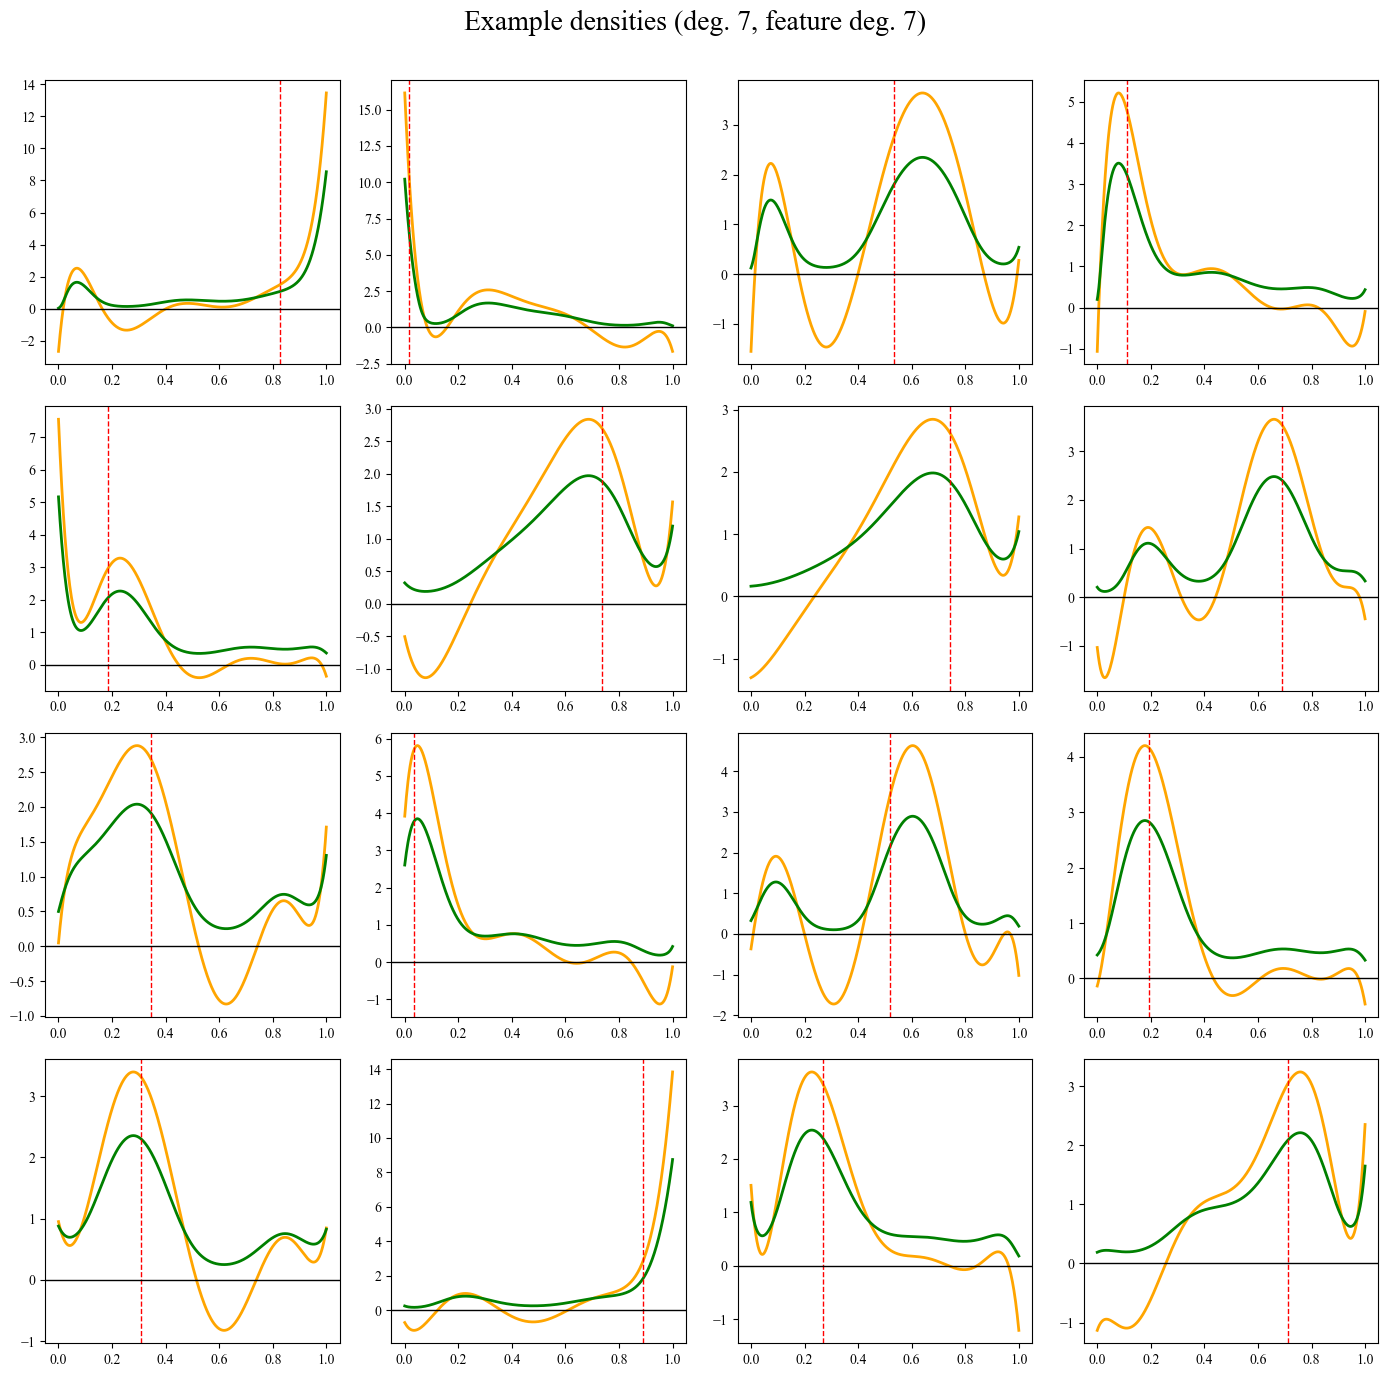

CL mean log-likelihood: 0.9081
CL test MSE: 24.2145


In [8]:
eval(X_train_norm, X_test_norm,
     y_train_norm, y_test_norm,
     y_test, y_denorm,
     N_feature=7, N_target=7, 
     method="softplus")

In [ ]:
ll, mse, coeffs_list = cv_eval(X, y, N_feature=7, N_target=7, 
                               method="softplus")
results["softplus"] = (ll, mse, coeffs_list)

In [10]:
from src.cv import print_cv_results
print_cv_results(ll, mse)


Log-likelihood:
  per fold: [0.85 0.93 0.82 0.86 0.89 0.87 0.82 0.81 0.82 0.82]
  mean LL : 0.8485
  std LL  : 0.0371

Mean square error:
  per fold: [14.   22.81 12.25 28.29 26.03 11.02 14.98 26.24 16.12 12.4 ]
  mean MSE: 18.4146
  std MSE : 6.3372


----- Target deg. 7, feature deg. 7 -----


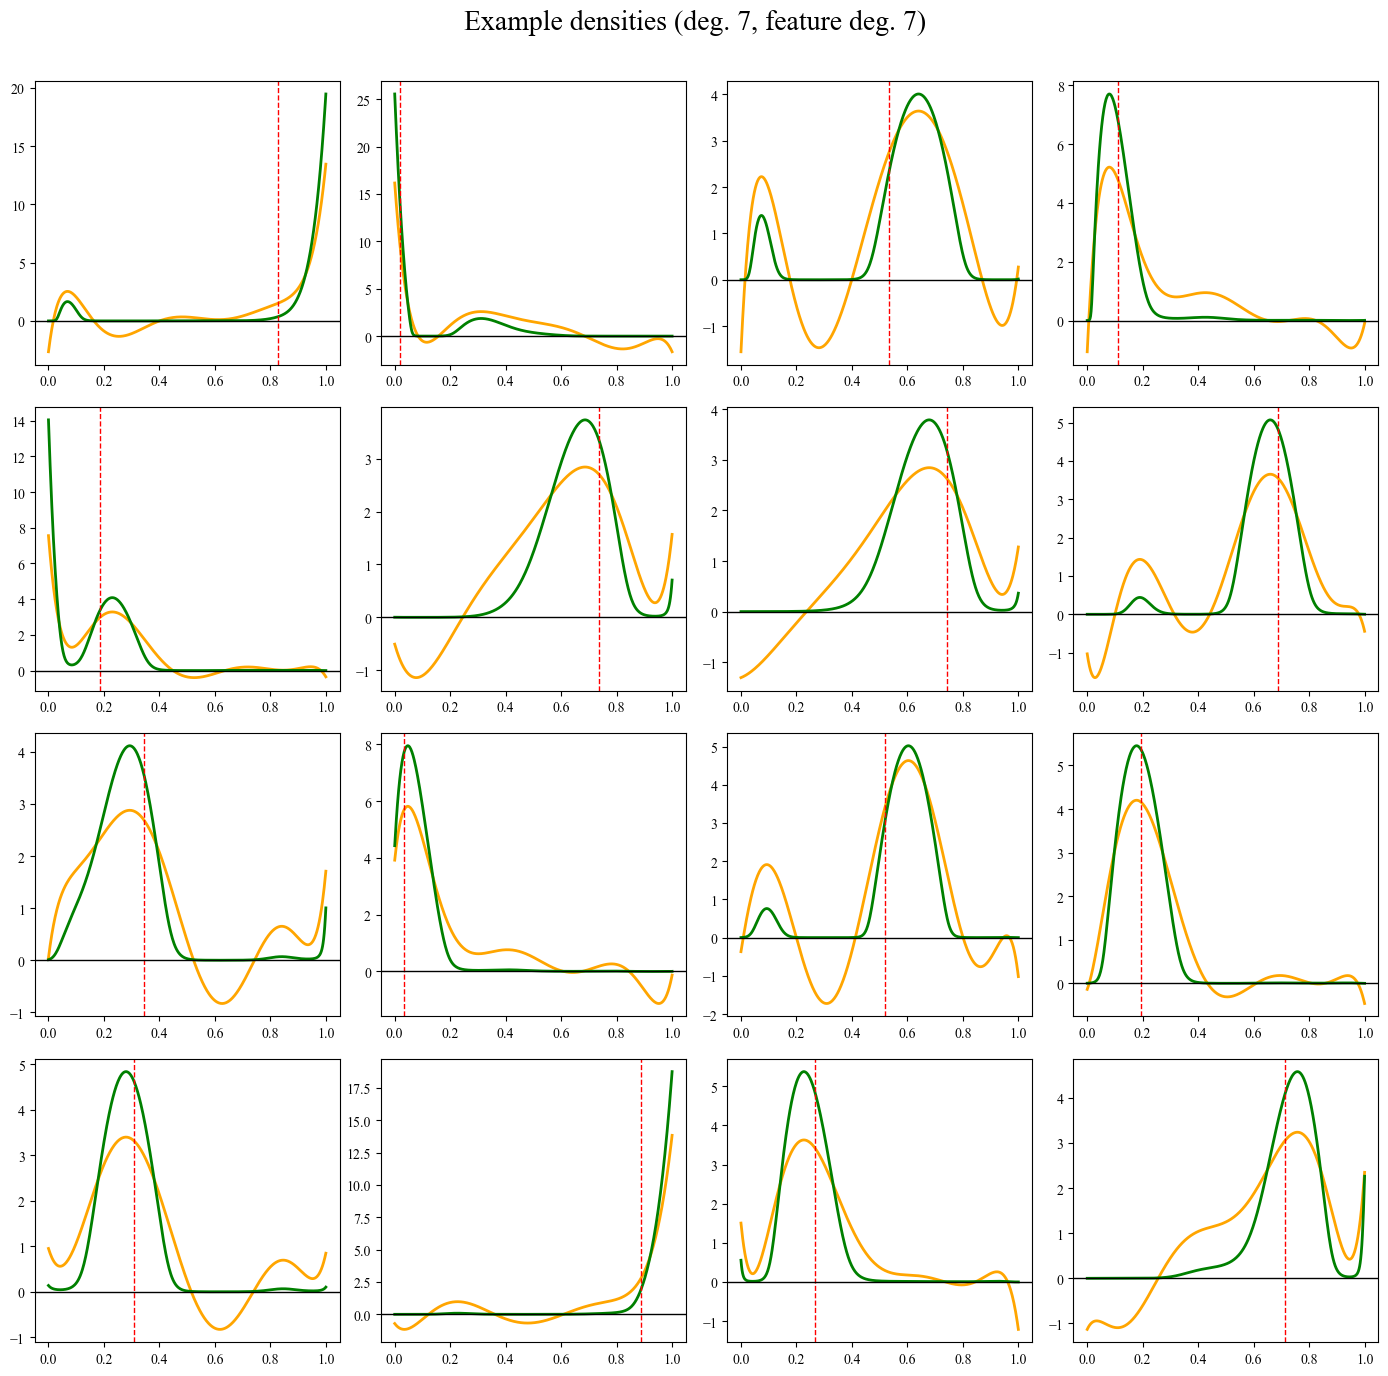

CL mean log-likelihood: 1.3264
CL test MSE: 6.5537


In [11]:
eval(X_train_norm, X_test_norm,
     y_train_norm, y_test_norm,
     y_test, y_denorm,
     N_feature=7, N_target=7, 
     method="softplus", a=3., b=100.)

In [ ]:
ll, mse, coeffs_list = cv_eval(X, y, N_feature=7, N_target=7, 
                               method="softplus", a=3., b=100.)
results["param-softplus"] = (ll, mse, coeffs_list)

In [13]:
from src.cv import print_cv_results
print_cv_results(ll, mse)


Log-likelihood:
  per fold: [1.2  1.44 1.25 1.23 1.29 1.29 1.12 1.23 1.12 1.26]
  mean LL : 1.2434
  std LL  : 0.0851

Mean square error:
  per fold: [4.84 7.72 3.44 8.39 8.49 4.66 7.14 9.03 6.59 3.35]
  mean MSE: 6.3646
  std MSE : 2.0285


----- Target deg. 7, feature deg. 7 -----


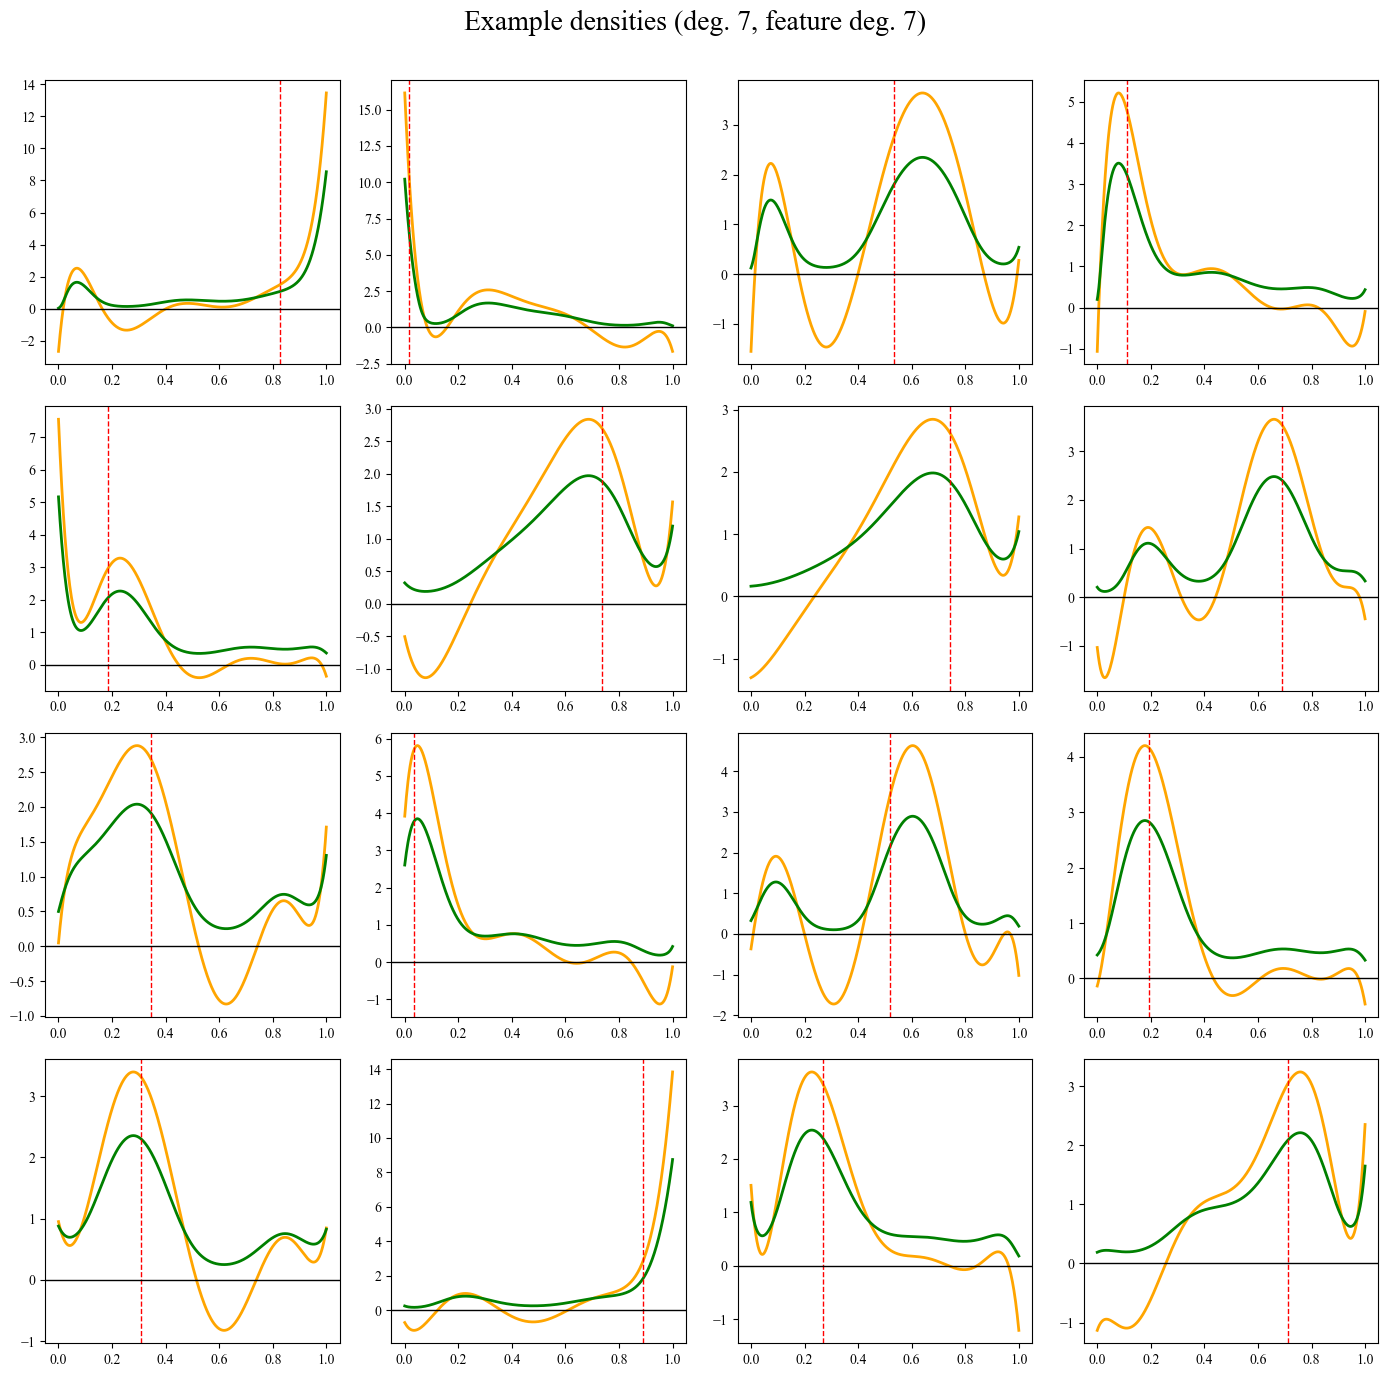

CL mean log-likelihood: 1.1354
CL test MSE: 14.2182


In [14]:
eval(X_train_norm, X_test_norm,
     y_train_norm, y_test_norm,
     y_test, y_denorm,
     N_feature=7, N_target=7, 
     method="clip")

In [ ]:
ll, mse, coeffs_list = cv_eval(X, y, N_feature=7, N_target=7, 
                               method="clip")
results["clip"] = (ll, mse, coeffs_list)

In [16]:
from src.cv import print_cv_results
print_cv_results(ll, mse)


Log-likelihood:
  per fold: [1.07 1.17 1.06 1.08 1.09 1.1  1.03 1.03 1.03 1.04]
  mean LL : 1.0700
  std LL  : 0.0401

Mean square error:
  per fold: [ 7.98 16.    6.17 17.62 15.37  6.23  8.58 16.24  9.15  6.03]
  mean MSE: 10.9378
  std MSE : 4.5224


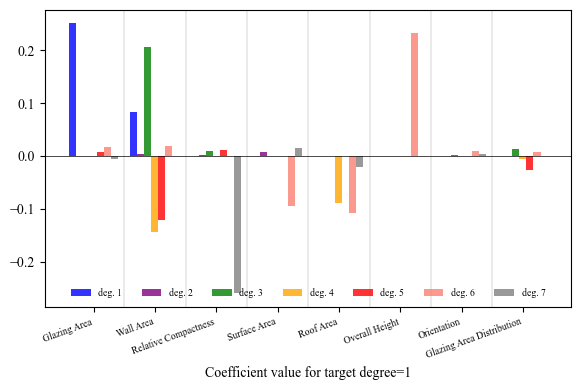

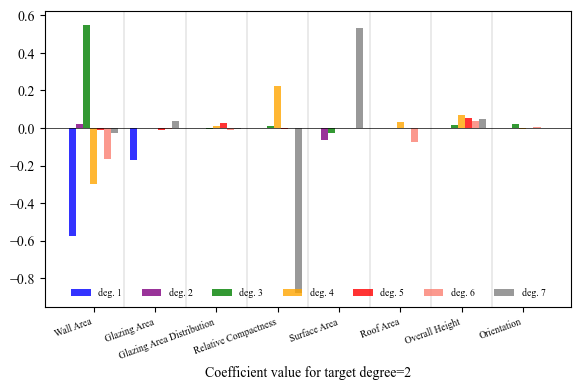

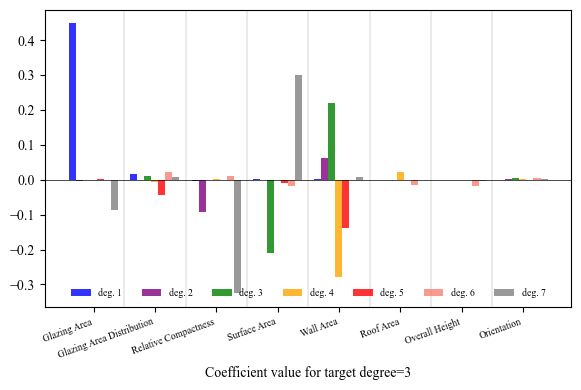

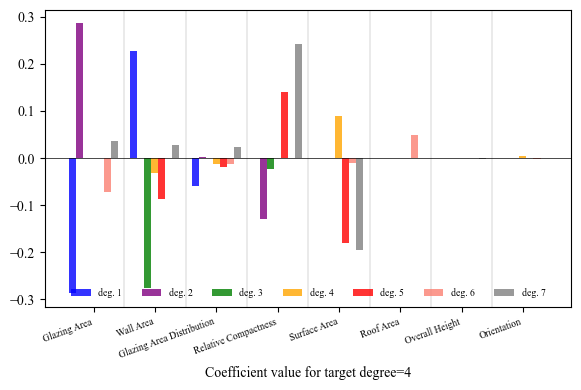

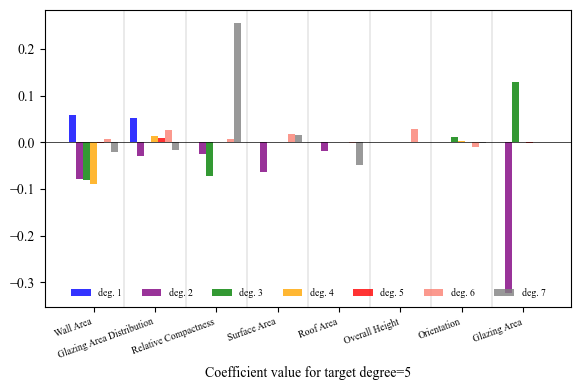

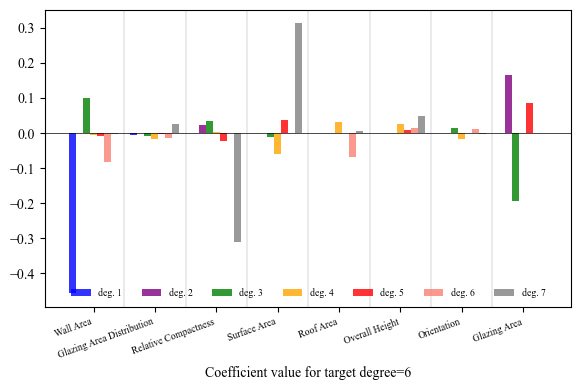

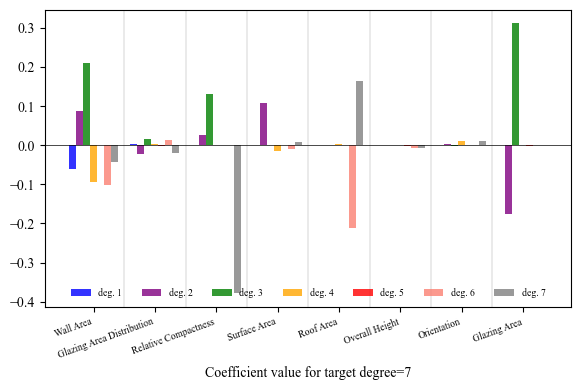

In [17]:
from src.weights import plot_coeffs, coeffs_mean

_, _, coeffs_list = results["param-softplus"]
coeffs = coeffs_mean(coeffs_list)

colors = ["blue", "purple", "green", "orange", "red", "salmon", "gray"]
N = 7
for deg in range(1, N+1):
    plot_coeffs(coeffs=coeffs[deg], target_deg=deg, colors=colors)

### Evaluation: model based on four independet variables

In [18]:
four_columns = ["Surface Area", "Roof Area", "Relative Compactness", "Glazing Area"]
X_four = X[four_columns]
X_train_four = X_train_norm[four_columns]
X_test_four = X_test_norm[four_columns]
results_four = {}

----- Target deg. 7, feature deg. 7 -----


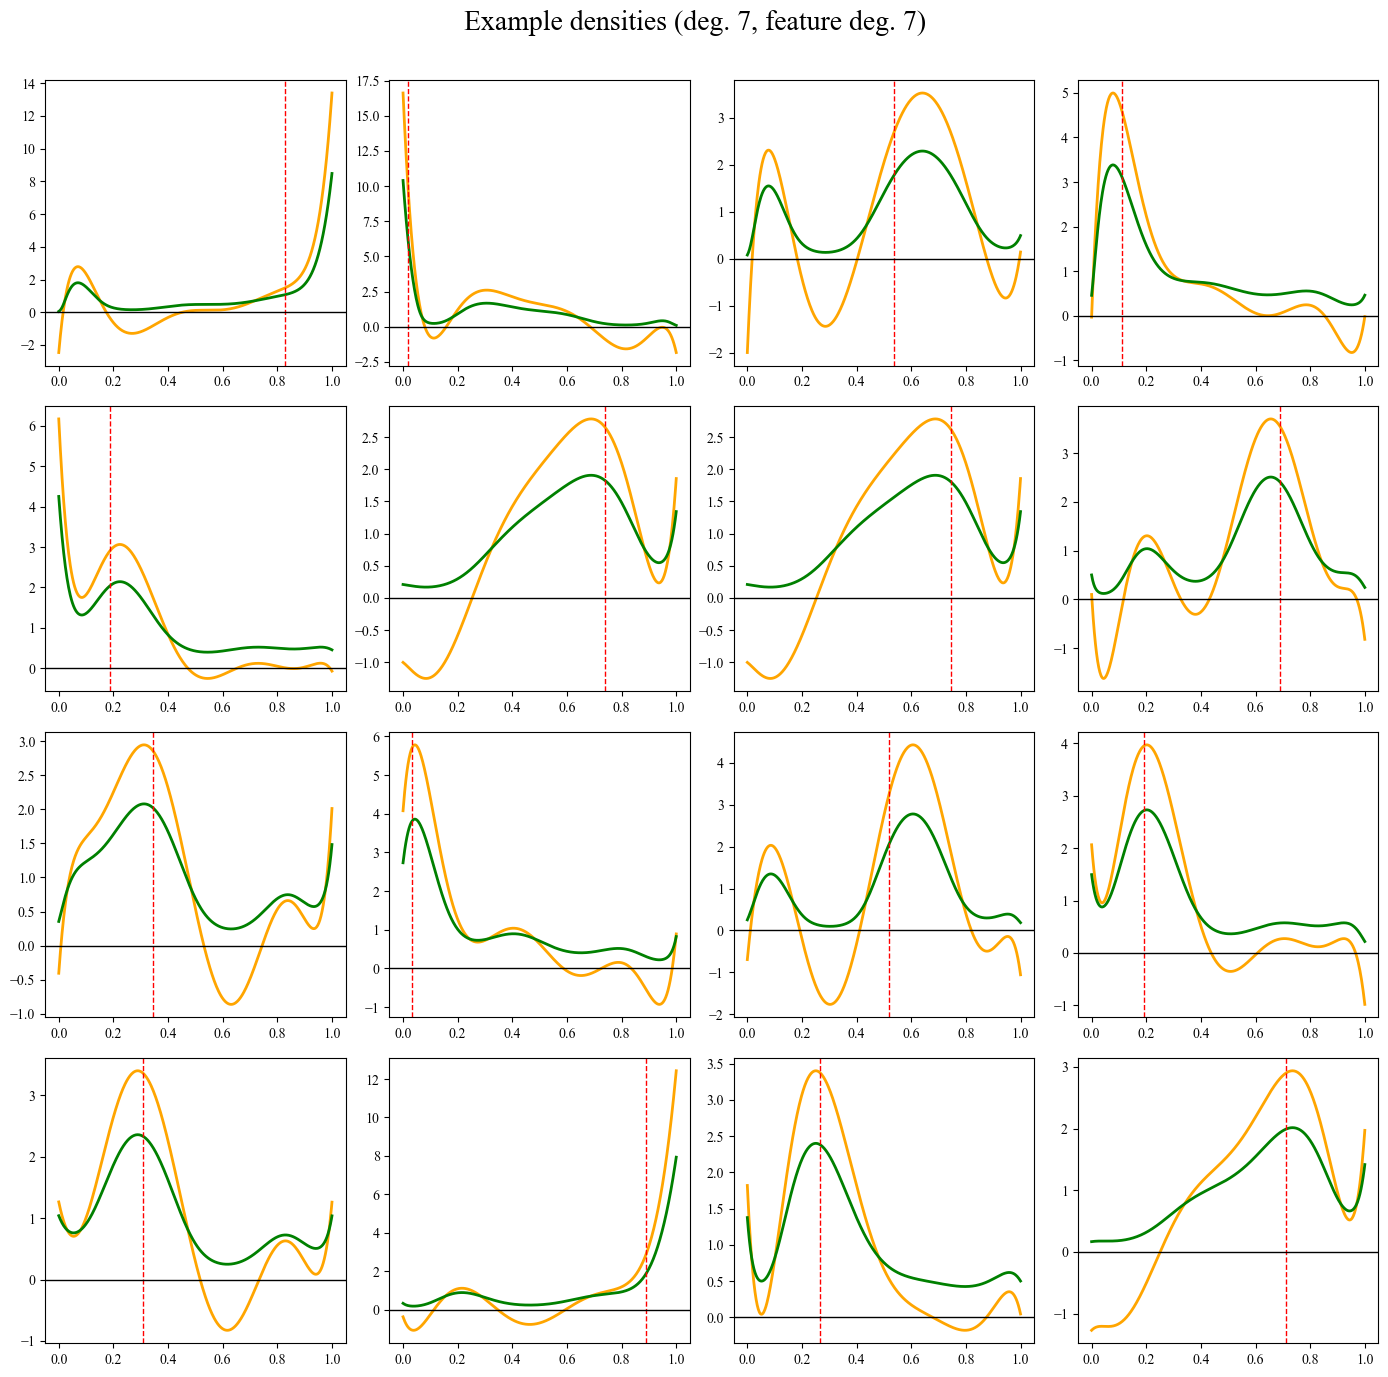

CL mean log-likelihood: 0.9094
CL test MSE: 24.4322


In [19]:
eval(X_train_four, X_test_four,
     y_train_norm, y_test_norm,
     y_test, y_denorm,
     N_feature=7, N_target=7,
     method="softplus")

In [ ]:
ll, mse, coeffs_list = cv_eval(X_four, y, N_feature=7, N_target=7, 
                               method="softplus")
results_four["softplus"] = (ll, mse, coeffs_list)

In [21]:
from src.cv import print_cv_results
print_cv_results(ll, mse)


Log-likelihood:
  per fold: [0.85 0.92 0.82 0.86 0.89 0.87 0.81 0.82 0.82 0.82]
  mean LL : 0.8483
  std LL  : 0.0354

Mean square error:
  per fold: [14.05 23.15 12.64 28.65 25.49 11.04 14.86 26.55 16.09 12.8 ]
  mean MSE: 18.5312
  std MSE : 6.3204


----- Target deg. 7, feature deg. 7 -----


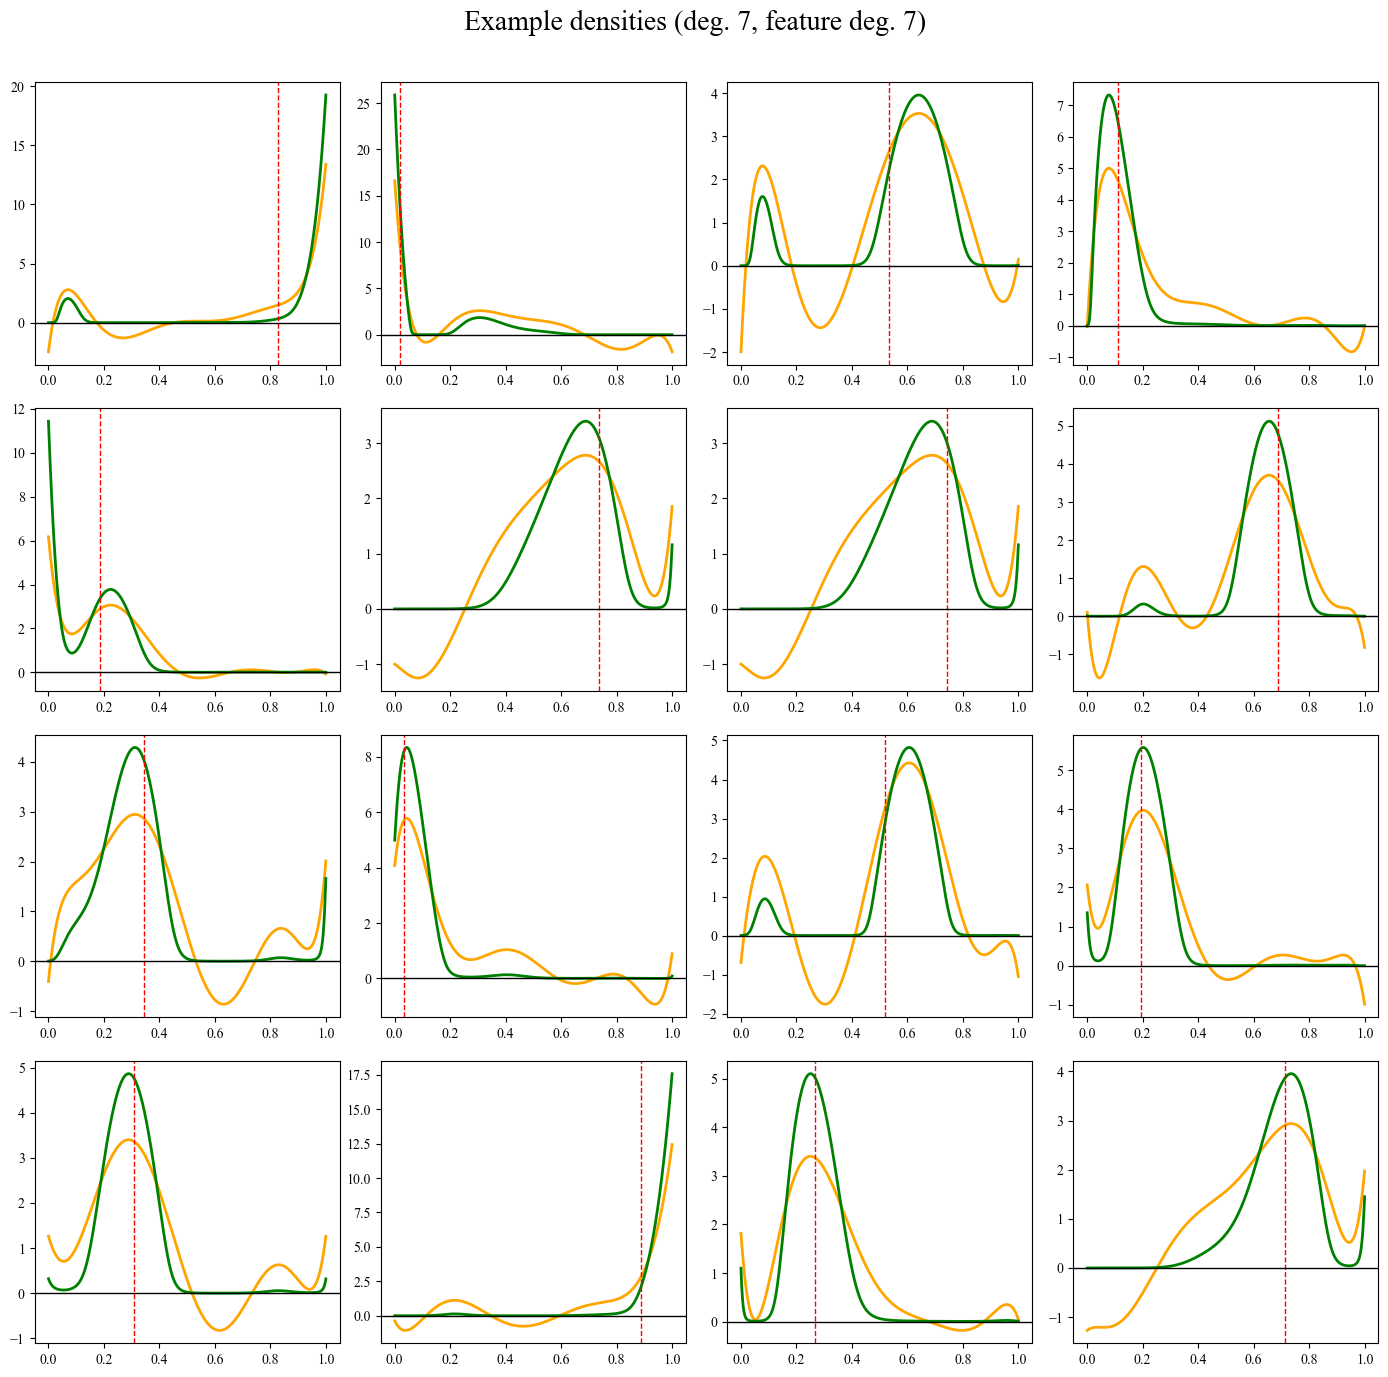

CL mean log-likelihood: 1.3371
CL test MSE: 7.1610


In [22]:
eval(X_train_four, X_test_four,
     y_train_norm, y_test_norm,
     y_test, y_denorm,
     N_feature=7, N_target=7,
     method="softplus", a=3., b=100.)

In [ ]:
ll, mse, coeffs_list = cv_eval(X_four, y, N_feature=7, N_target=7, 
                               method="softplus", a=3., b=100.)
results_four["param-softplus"] = (ll, mse, coeffs_list)

In [24]:
from src.cv import print_cv_results
print_cv_results(ll, mse)


Log-likelihood:
  per fold: [1.2  1.42 1.26 1.23 1.3  1.31 1.1  1.25 1.13 1.26]
  mean LL : 1.2451
  std LL  : 0.0867

Mean square error:
  per fold: [4.72 8.7  3.57 9.   8.21 4.06 7.37 8.68 6.75 3.76]
  mean MSE: 6.4811
  std MSE : 2.1172


----- Target deg. 7, feature deg. 7 -----


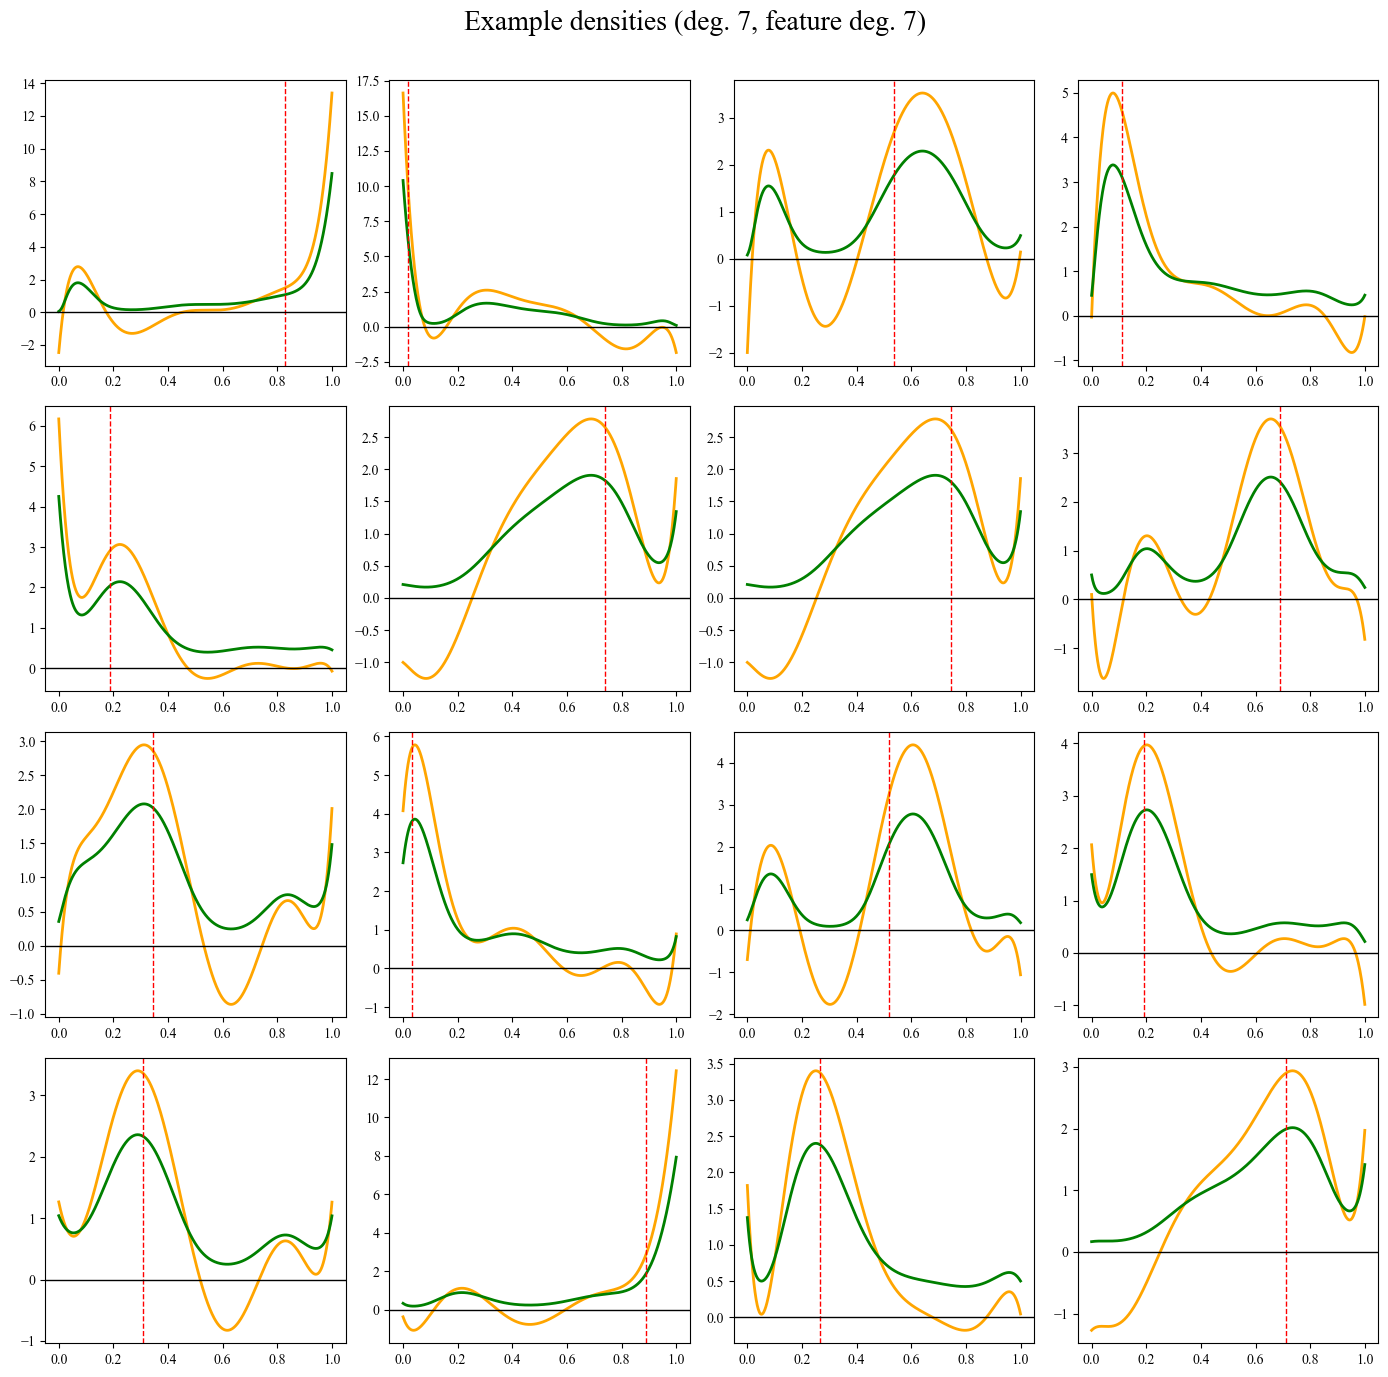

CL mean log-likelihood: 1.1396
CL test MSE: 14.1255


In [25]:
eval(X_train_four, X_test_four,
     y_train_norm, y_test_norm,
     y_test, y_denorm,
     N_feature=7, N_target=7,
     method="clip")

In [ ]:
ll, mse, coeffs_list = cv_eval(X_four, y, N_feature=7, N_target=7, 
                               method="clip")
results_four["clip"] = (ll, mse, coeffs_list)

In [27]:
from src.cv import print_cv_results
print_cv_results(ll, mse)


Log-likelihood:
  per fold: [1.07 1.16 1.05 1.08 1.1  1.1  1.03 1.05 1.03 1.05]
  mean LL : 1.0722
  std LL  : 0.0379

Mean square error:
  per fold: [ 7.74 16.31  6.65 18.11 14.27  6.17  8.55 16.01  9.46  6.37]
  mean MSE: 10.9632
  std MSE : 4.4421


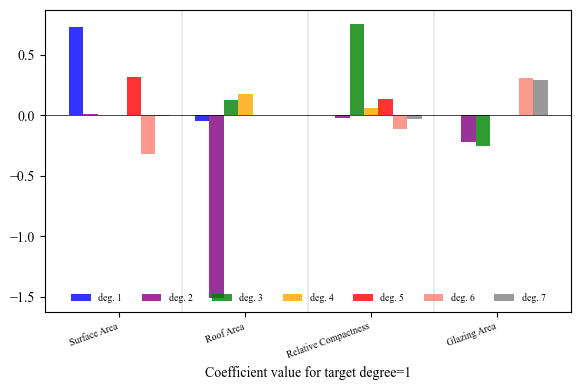

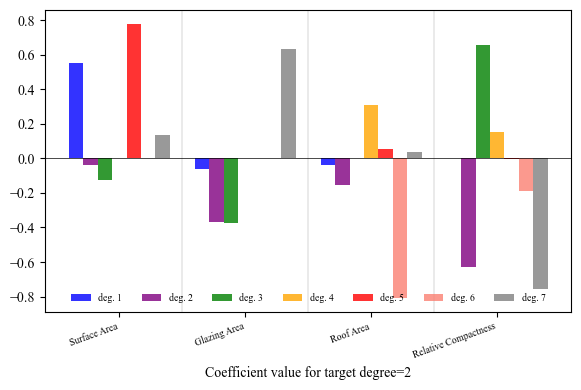

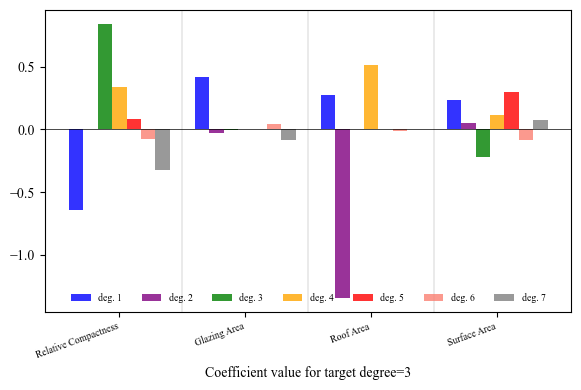

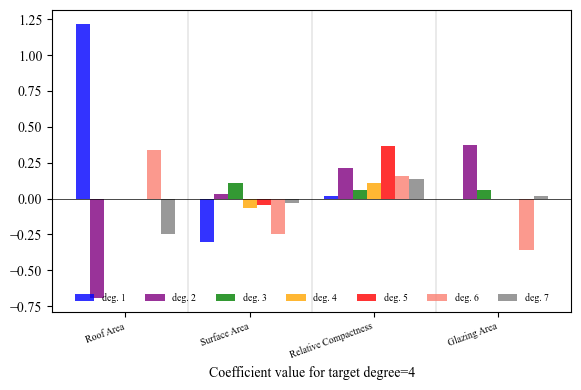

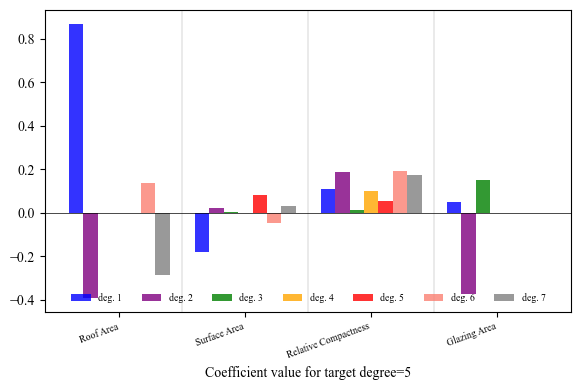

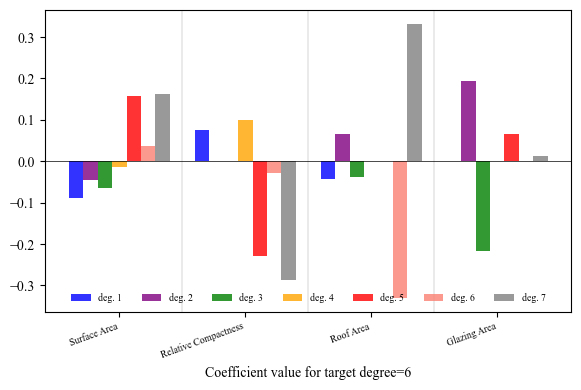

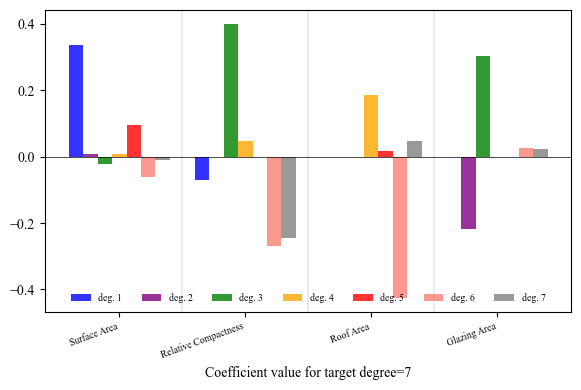

In [28]:
from src.weights import plot_coeffs, coeffs_mean

_, _, coeffs_list = results_four["param-softplus"]
coeffs = coeffs_mean(coeffs_list)

colors = ["blue", "purple", "green", "orange", "red", "salmon", "gray"]
N = 7
for deg in range(1, N+1):
    plot_coeffs(coeffs=coeffs[deg], target_deg=deg, colors=colors)

### Evaluation: model based on six independet variables

In [29]:
six_columns = ["Surface Area", "Roof Area", "Relative Compactness", "Glazing Area", "Wall Area", "Overall Height"]
X_six = X[six_columns]
X_train_six = X_train_norm[six_columns]
X_test_six = X_test_norm[six_columns]
results_six = {}

----- Target deg. 7, feature deg. 7 -----


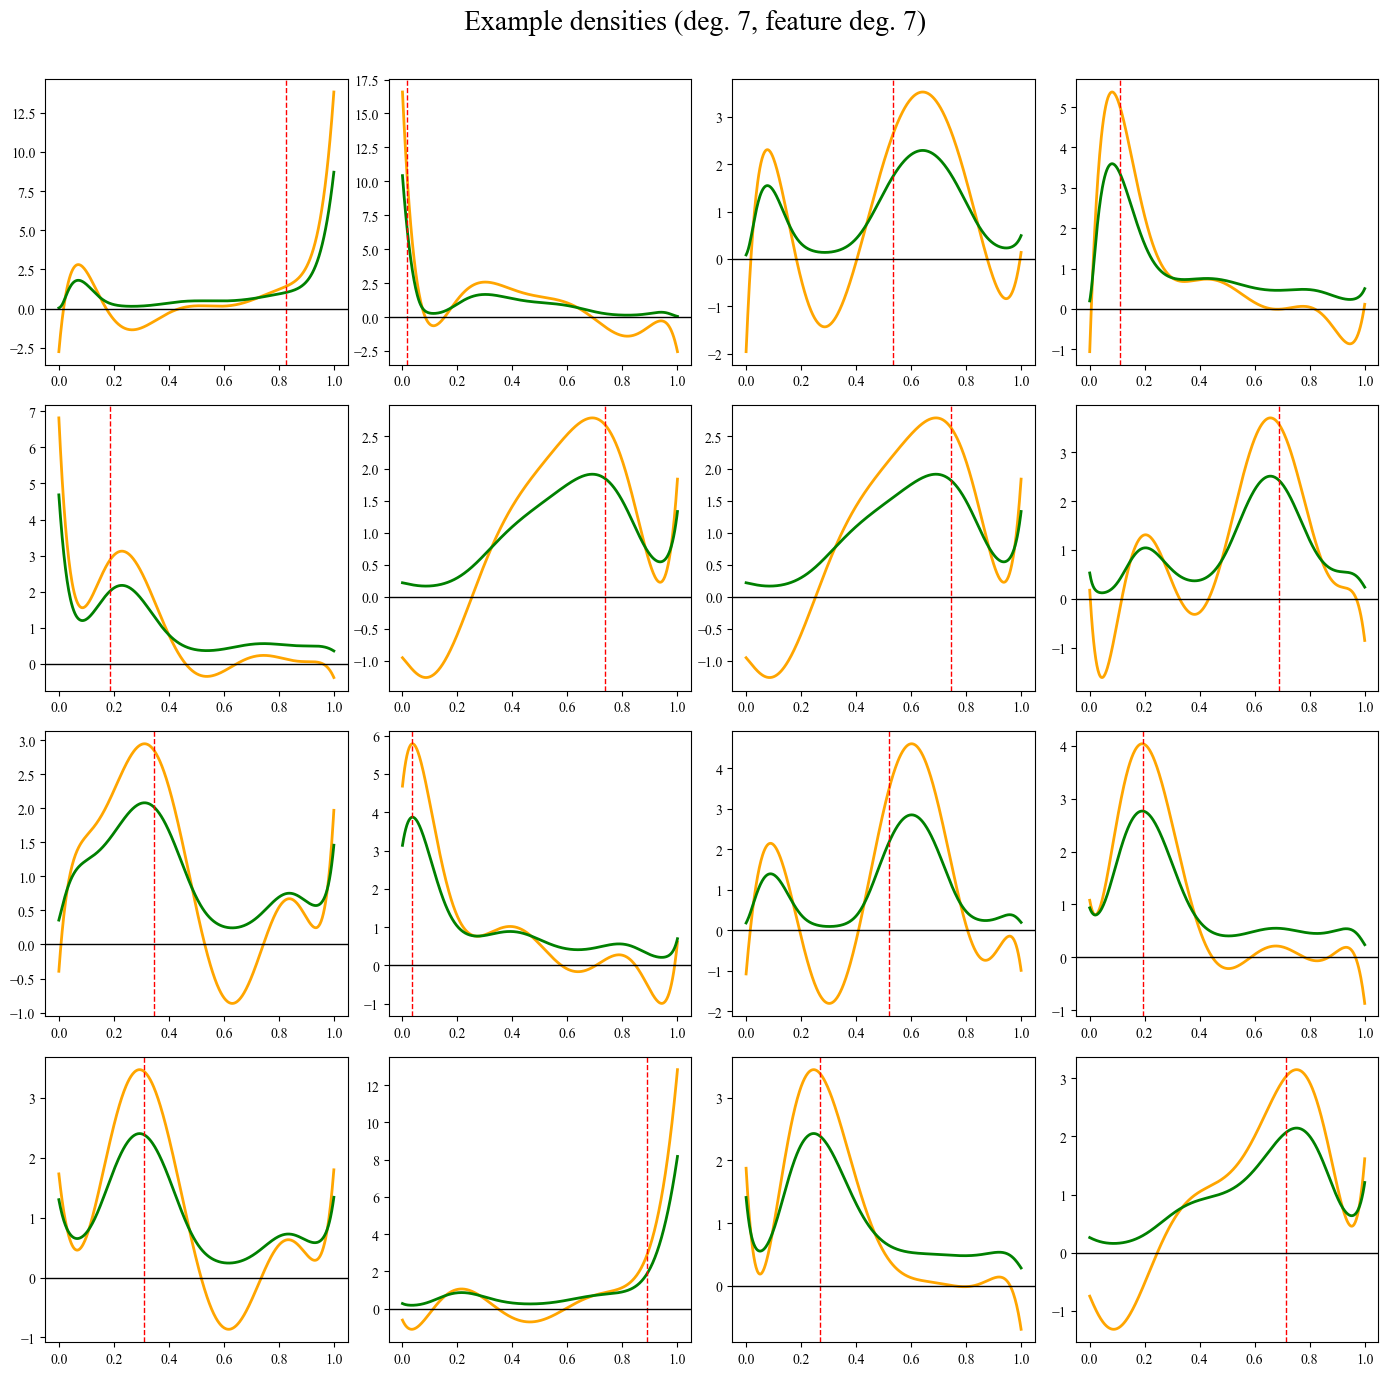

CL mean log-likelihood: 0.9147
CL test MSE: 24.3712


In [30]:
eval(X_train_six, X_test_six,
     y_train_norm, y_test_norm,
     y_test, y_denorm,
     N_feature=7, N_target=7,
     method="softplus")

In [ ]:
ll, mse, coeffs_list = cv_eval(X_six, y, N_feature=7, N_target=7, 
                               method="softplus")
results_six["softplus"] = (ll, mse, coeffs_list)

In [32]:
from src.cv import print_cv_results
print_cv_results(ll, mse)


Log-likelihood:
  per fold: [0.86 0.94 0.83 0.87 0.9  0.87 0.82 0.82 0.82 0.82]
  mean LL : 0.8537
  std LL  : 0.0383

Mean square error:
  per fold: [13.9  22.86 12.37 28.39 25.77 10.92 14.51 26.02 15.94 12.45]
  mean MSE: 18.3133
  std MSE : 6.3341


----- Target deg. 7, feature deg. 7 -----


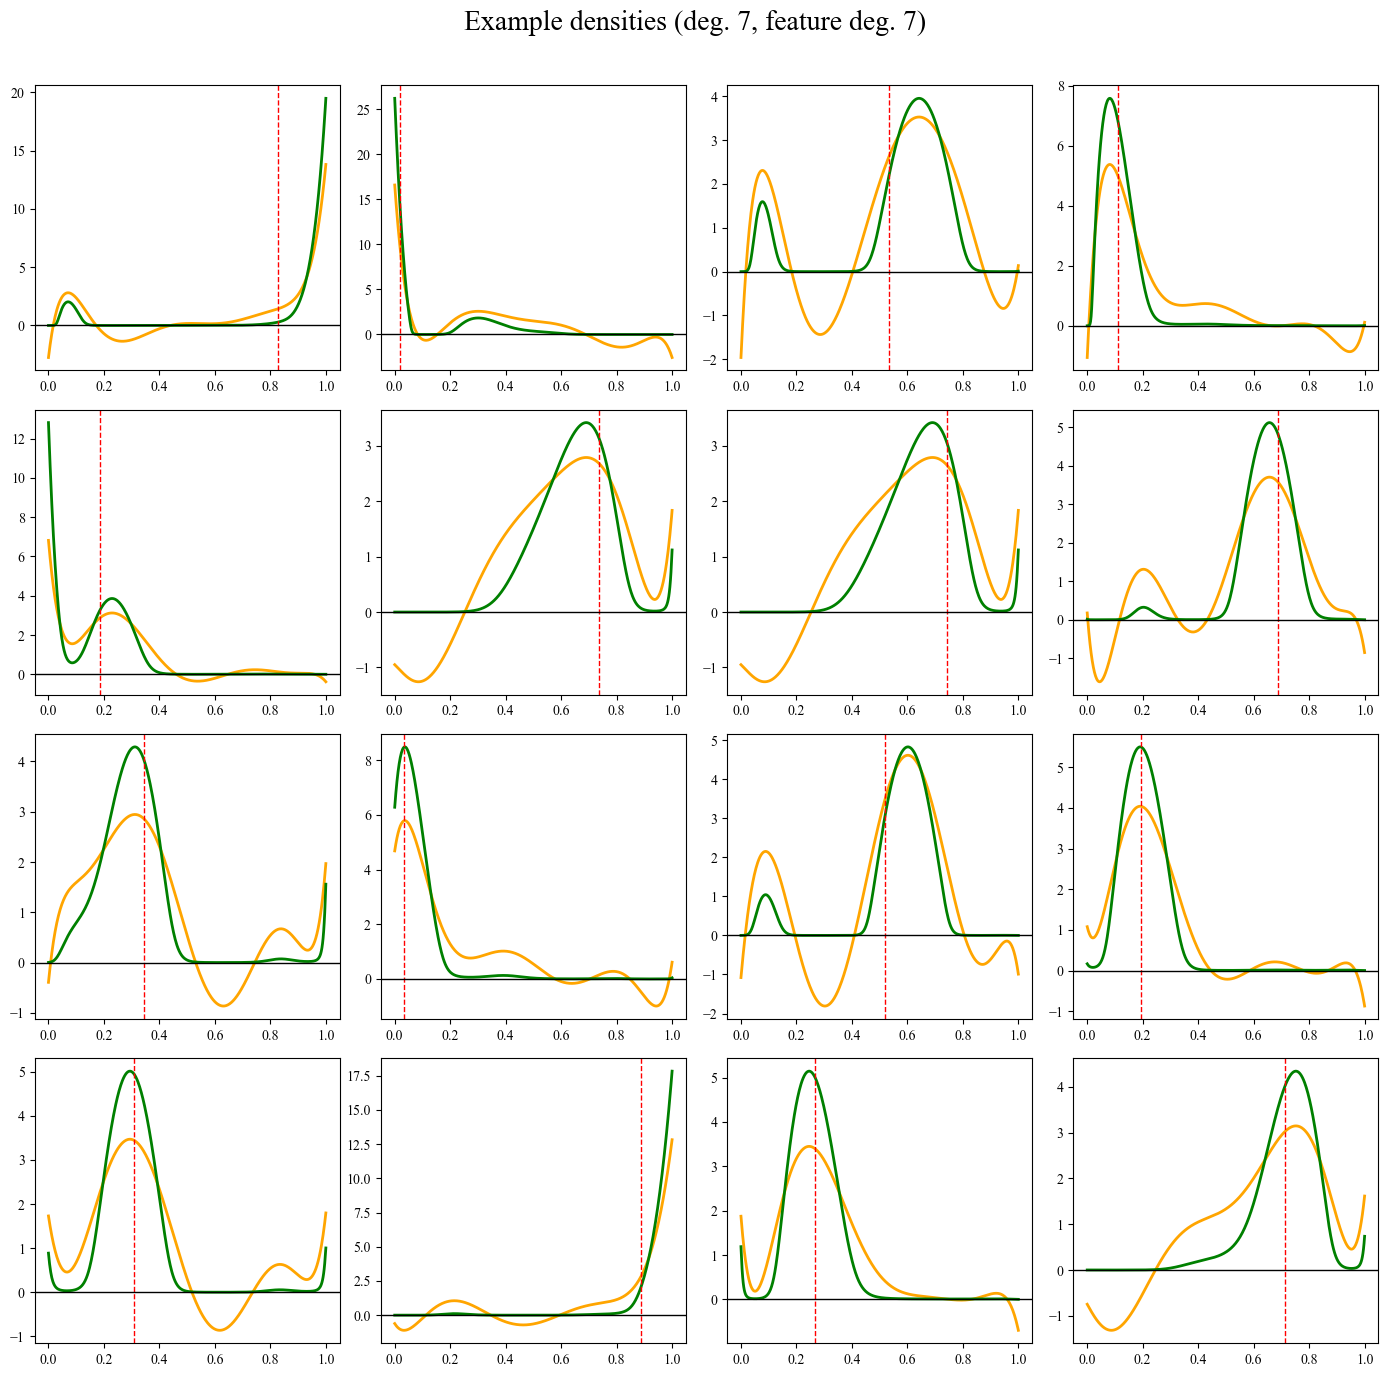

CL mean log-likelihood: 1.3360
CL test MSE: 7.0420


In [33]:
eval(X_train_six, X_test_six,
     y_train_norm, y_test_norm,
     y_test, y_denorm,
     N_feature=7, N_target=7,
     method="softplus", a=3., b=100.)

In [ ]:
ll, mse, coeffs_list = cv_eval(X_six, y, N_feature=7, N_target=7, 
                               method="softplus", a=3., b=100.)
results_six["param-softplus"] = (ll, mse, coeffs_list)

In [35]:
from src.cv import print_cv_results
print_cv_results(ll, mse)


Log-likelihood:
  per fold: [1.23 1.46 1.27 1.25 1.3  1.29 1.12 1.25 1.11 1.27]
  mean LL : 1.2536
  std LL  : 0.0915

Mean square error:
  per fold: [4.73 7.65 3.34 8.42 8.19 4.34 7.18 8.51 6.62 3.43]
  mean MSE: 6.2397
  std MSE : 1.9723


----- Target deg. 7, feature deg. 7 -----


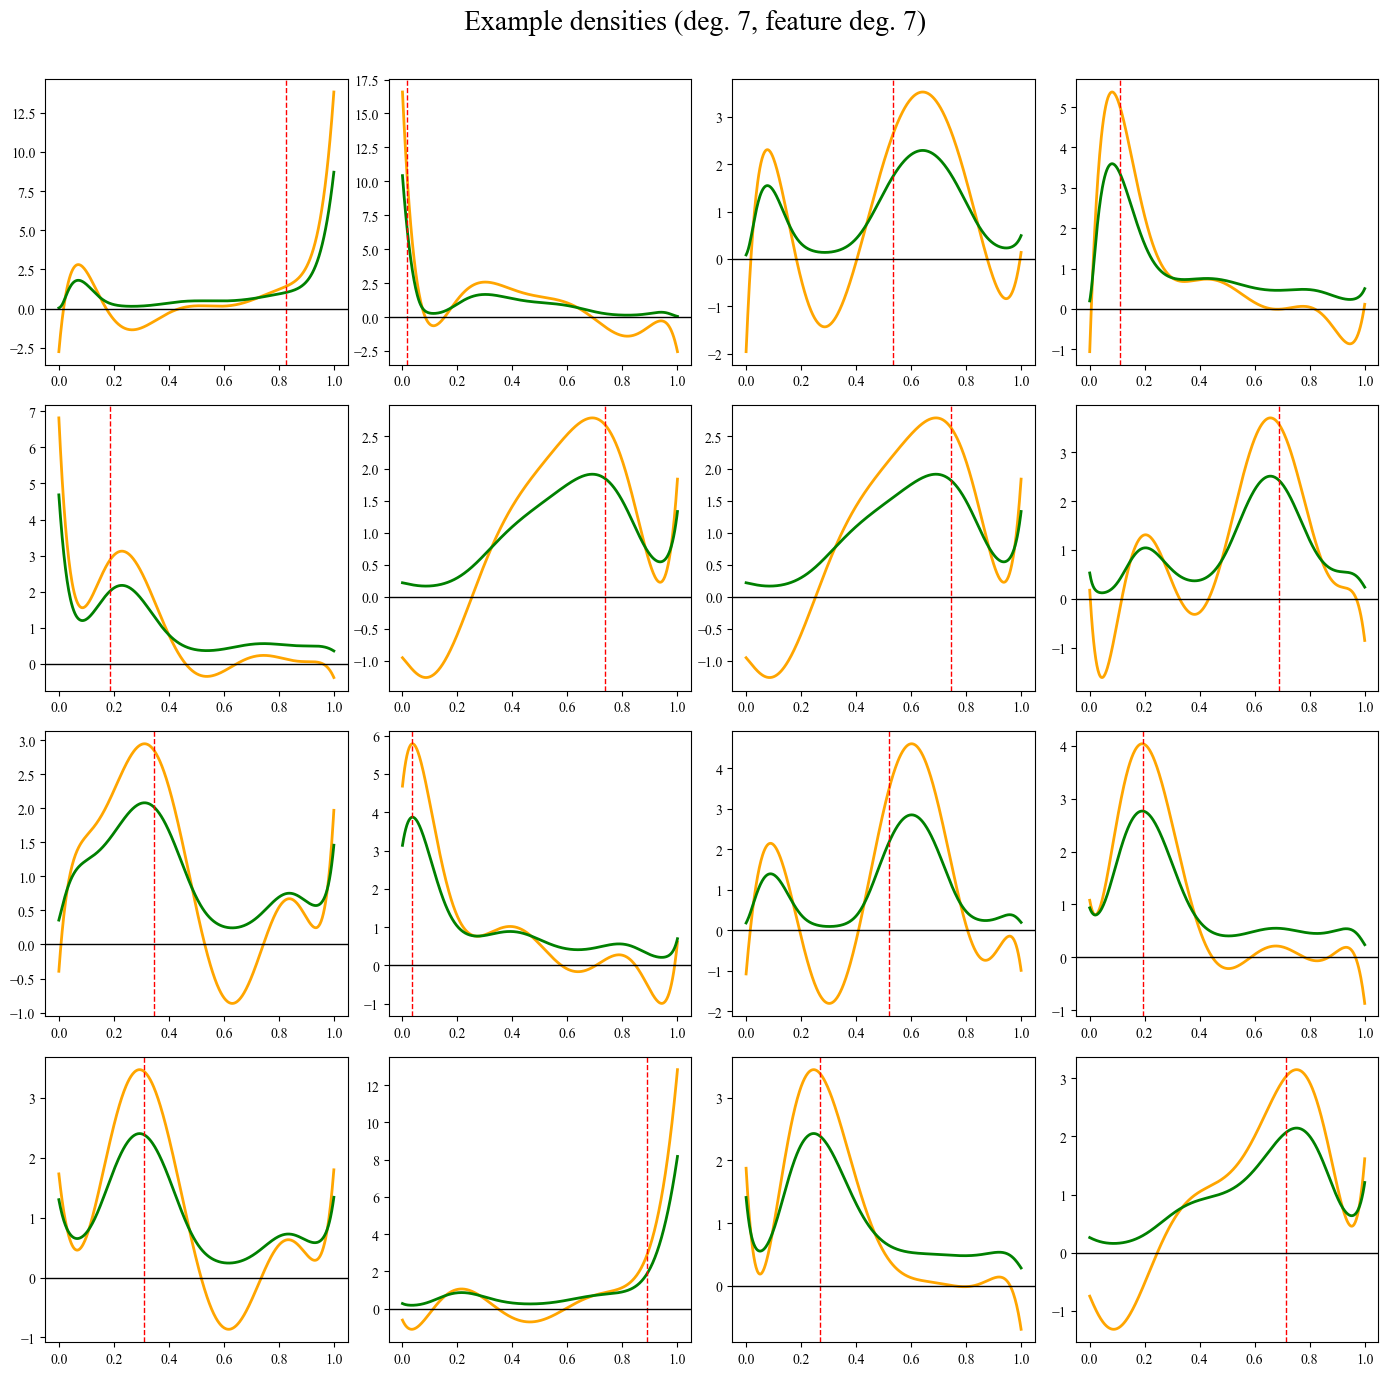

CL mean log-likelihood: 1.1425
CL test MSE: 14.2472


In [36]:
eval(X_train_six, X_test_six,
     y_train_norm, y_test_norm,
     y_test, y_denorm,
     N_feature=7, N_target=7,
     method="clip")

In [ ]:
ll, mse, coeffs_list = cv_eval(X_six, y, N_feature=7, N_target=7, 
                               method="clip")
results_six["clip"] = (ll, mse, coeffs_list)

In [38]:
from src.cv import print_cv_results
print_cv_results(ll, mse)


Log-likelihood:
  per fold: [1.09 1.18 1.06 1.09 1.1  1.1  1.03 1.05 1.03 1.05]
  mean LL : 1.0779
  std LL  : 0.0421

Mean square error:
  per fold: [ 7.54 15.97  6.27 17.87 14.63  6.29  8.55 15.57  9.21  6.06]
  mean MSE: 10.7957
  std MSE : 4.4245


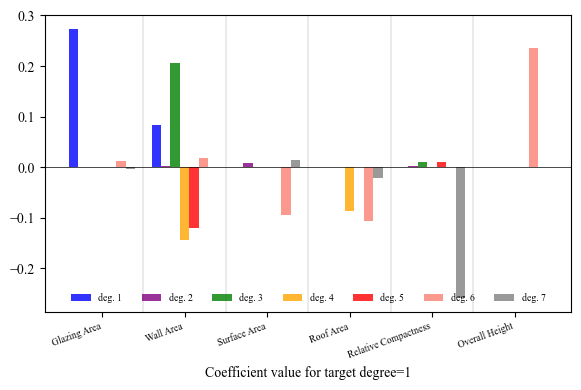

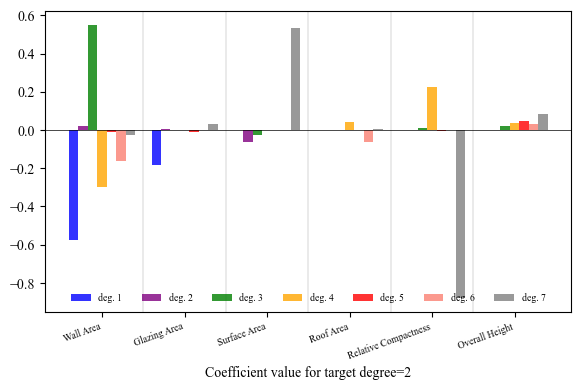

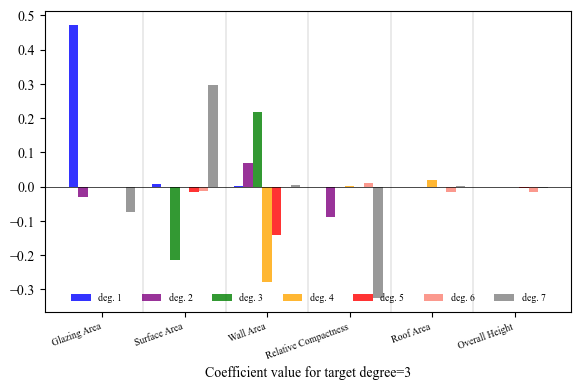

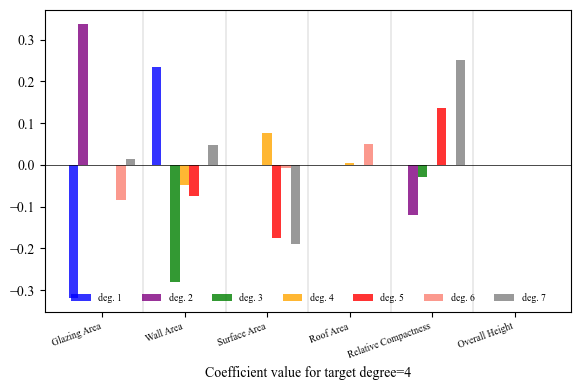

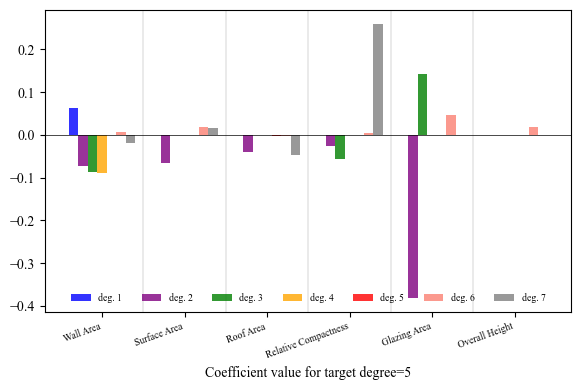

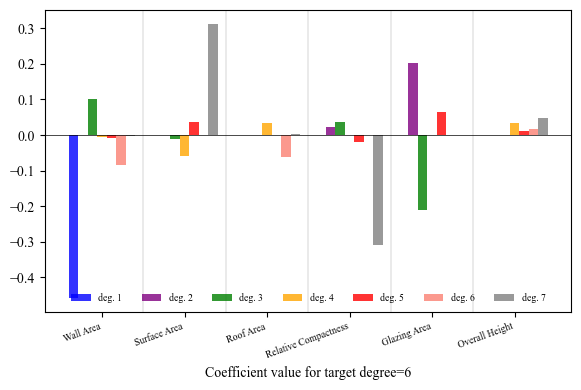

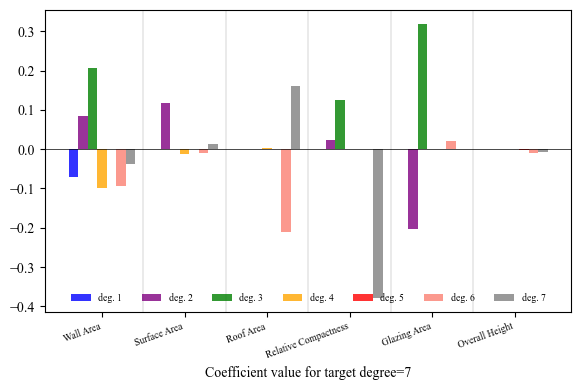

In [39]:
from src.weights import plot_coeffs, coeffs_mean

_, _, coeffs_list = results_six["param-softplus"]
coeffs = coeffs_mean(coeffs_list)

colors = ["blue", "purple", "green", "orange", "red", "salmon", "gray"]
N = 7
for deg in range(1, N+1):
    plot_coeffs(coeffs=coeffs[deg], target_deg=deg, colors=colors)